# NE-SW ca. 1160 Ma paleomagnetic pole## Geologic Context- Terrane: Laurentia-Greenland.- Compiled unit/pole label: NE-SW Trending Dyke Swarm.## Paleomagnetic And Rock Magnetic Data- B = 18 sites, N = 102 samples; mean direction DEC/INC = 282.9°/50.9°; K = 46.0.- Rock-magnetic interpretation: expand with mineral carriers/coercivity/unblocking evidence from source studies.## Age Constraints- Current bracket: lomagage 1155.0 Ma, himagage 1165.0 Ma.- Compilation method note: younger than 1163 giant dykes, older than 1156±1 central Tugtutoq pluton, s## References- Paleomagnetic source: Piper, J.D.A. (1992). The palaeomagnetism of major (Middle Proterozoic) igneous complexes, South Greenland and the Gardar apparent polar wander track. Precambr.Res., 54, 153-172.- Geochronology / age-constraint note (compilation): younger than 1163 giant dykes, older than 1156±1 central Tugtutoq pluton, s

In [1]:
import pole_tools as pt
import pmagpy.ipmag as ipmag
import pmagpy.pmag as pmag
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

Laurentia_poles = pt.get_Laurentia_poles()
Laurentia_stricto_poles = pt.get_Laurentia_stricto_poles()

%config InlineBackend.figure_format='retina'
%matplotlib inline

## Pole from the Evans et al. (2021) compilation

The pole is read directly from the previous Nordic compilation (`data/Evans_et_al_2021_compilation.csv`). No site-level recomputation is performed because the underlying directions are not digitized in this repository; the published pole is carried forward into the Nordic compilation format.

In [2]:
evans = pd.read_csv('../data/Evans_et_al_2021_compilation.csv')
row = evans[evans['ROCKNAME'] == 'NE-SW Trending Dyke Swarm'].iloc[0]

pole_mean = {'dec': float(row['PLONG']), 'inc': float(row['PLAT']),
             'alpha95': float(row['A95']), 'n': int(float(row['B']))}
dir_mean = {'dec': float(row['DEC']), 'inc': float(row['INC']),
            'alpha95': float(row['ED95']), 'k': float(row['KD'])}

print('NE-SW Trending Dyke Swarm' + ' pole (Evans et al., 2021 compilation):')
print(f"  PLAT {pole_mean['inc']}  PLON {pole_mean['dec']}  A95 {pole_mean['alpha95']}  B {pole_mean['n']} sites")
print(f"  mean direction Dec {dir_mean['dec']}  Inc {dir_mean['inc']}  (%REV {row['%REV']})")

NE-SW Trending Dyke Swarm pole (Evans et al., 2021 compilation):
  PLAT 33.4  PLON 230.8  A95 5.7  B 18 sites
  mean direction Dec 282.9  Inc 50.9  (%REV 0or100)


## Statistical assessment (Meert et al., 2020; R2)

In [3]:
pt.R2_test('NE-SW Trending Dyke Swarm', Laurentia_poles)

N = 102 (N ≥ 25; sufficient sample number);
B = 18 (B ≥ 8; sufficient site number);
K = 46 (70 ≥ K ≥ 10; meets PSV criteria);
A_95 of 5.7 passes Deenen et al. (2011) criteria of being between 3.8 and 13.3 for this number of sites


## Euler rotation into the Laurentia reference frame

These rocks belong to the Laurentia-Greenland terrane, so the pole must be restored into the Laurentia reference frame before it is compared with the Laurentia APWP. The Greenland-to-Laurentia rotation of Roest & Srivastava (1989), associated with Cenozoic opening of Baffin Bay and the Labrador Sea, is applied with `pmag.pt_rot`: Euler pole 67.5 deg N / -118.5 deg E, angle -13.8 deg. This is the same rotation `get_Laurentia_poles` uses to place the Greenland comparison poles into Laurentia coordinates.

In [4]:
euler_greenland = pt.TERRANE_EULER_POLES['Laurentia-Greenland']   # [67.5, -118.5, -13.8]; Roest & Srivastava (1989)
rlat, rlon = pmag.pt_rot(euler_greenland, [pole_mean['inc']], [pole_mean['dec']])
pole_rotated = {'inc': rlat[0], 'dec': rlon[0], 'alpha95': pole_mean['alpha95']}
print(f"unrotated (present-day Greenland frame): {pole_mean['inc']:.1f} N / {pole_mean['dec']:.1f} E")
print(f"rotated into the Laurentia frame:        {pole_rotated['inc']:.1f} N / {pole_rotated['dec']:.1f} E")

unrotated (present-day Greenland frame): 33.4 N / 230.8 E
rotated into the Laurentia frame:        34.8 N / 221.5 E


## Position within the Laurentia apparent polar wander path

The pole is shown in its unrotated position (present-day Greenland coordinates, off the Laurentia path) and rotated into the Laurentia frame (restored onto the path). The comparison APWP poles are all shown in Laurentia coordinates.

posx and posy should be finite values
posx and posy should be finite values


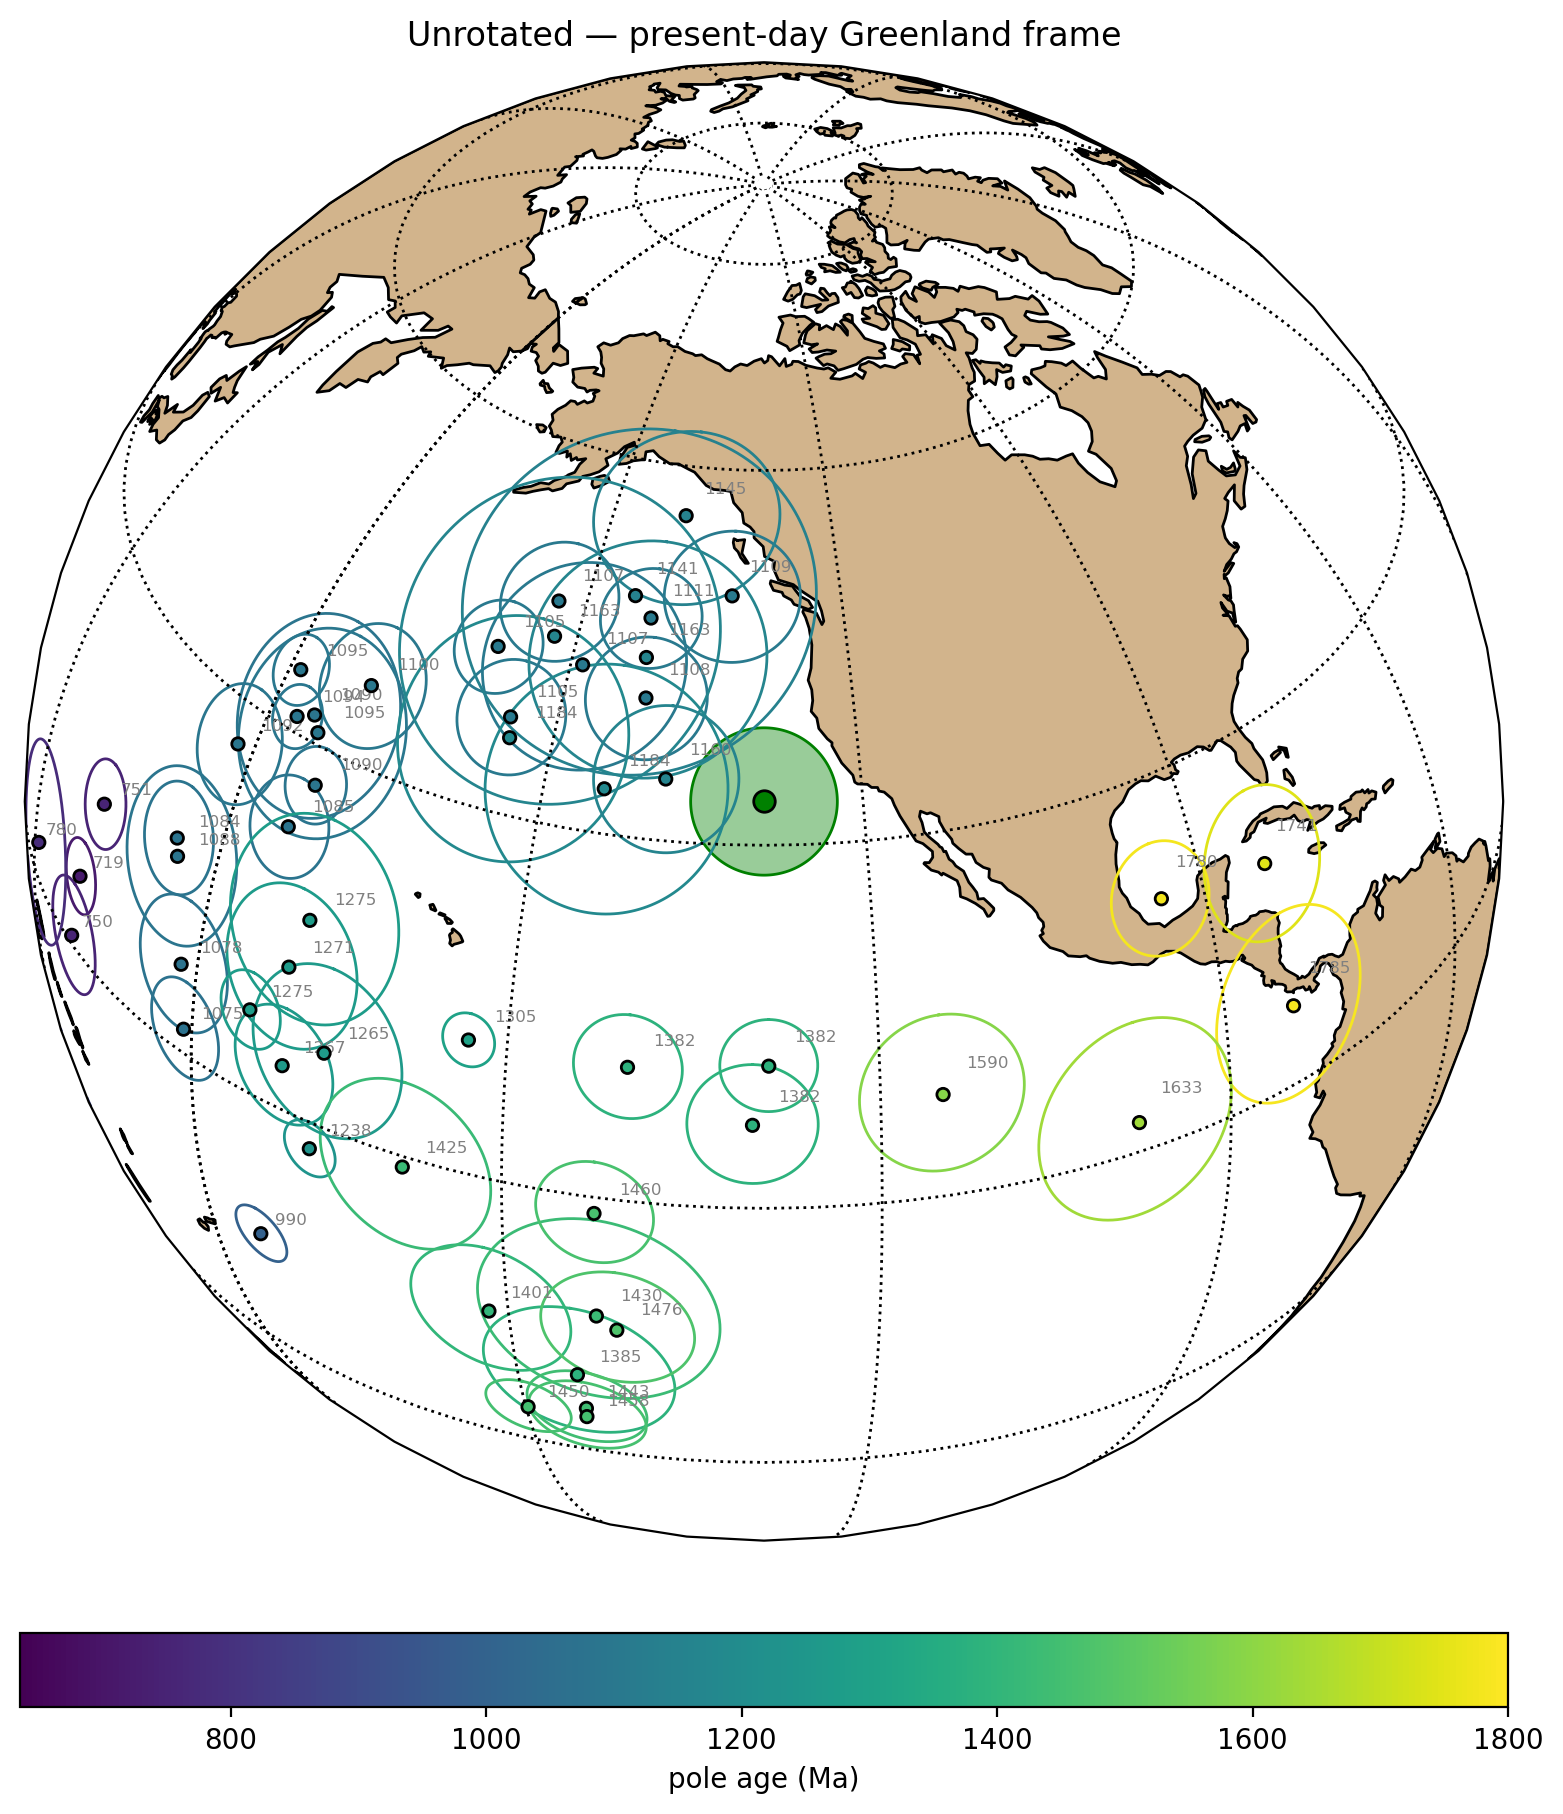

In [5]:
ax = pt.plot_apwp_context(Laurentia_poles, pole_mean['inc'], pole_mean['dec'],
                          pole_mean['alpha95'], age_min=635, age_max=1800,
                          projection='orthographic',
                          central_longitude=pole_mean['dec'],
                          central_latitude=pole_mean['inc'])
plt.title('Unrotated \u2014 present-day Greenland frame')
plt.show()

posx and posy should be finite values
posx and posy should be finite values


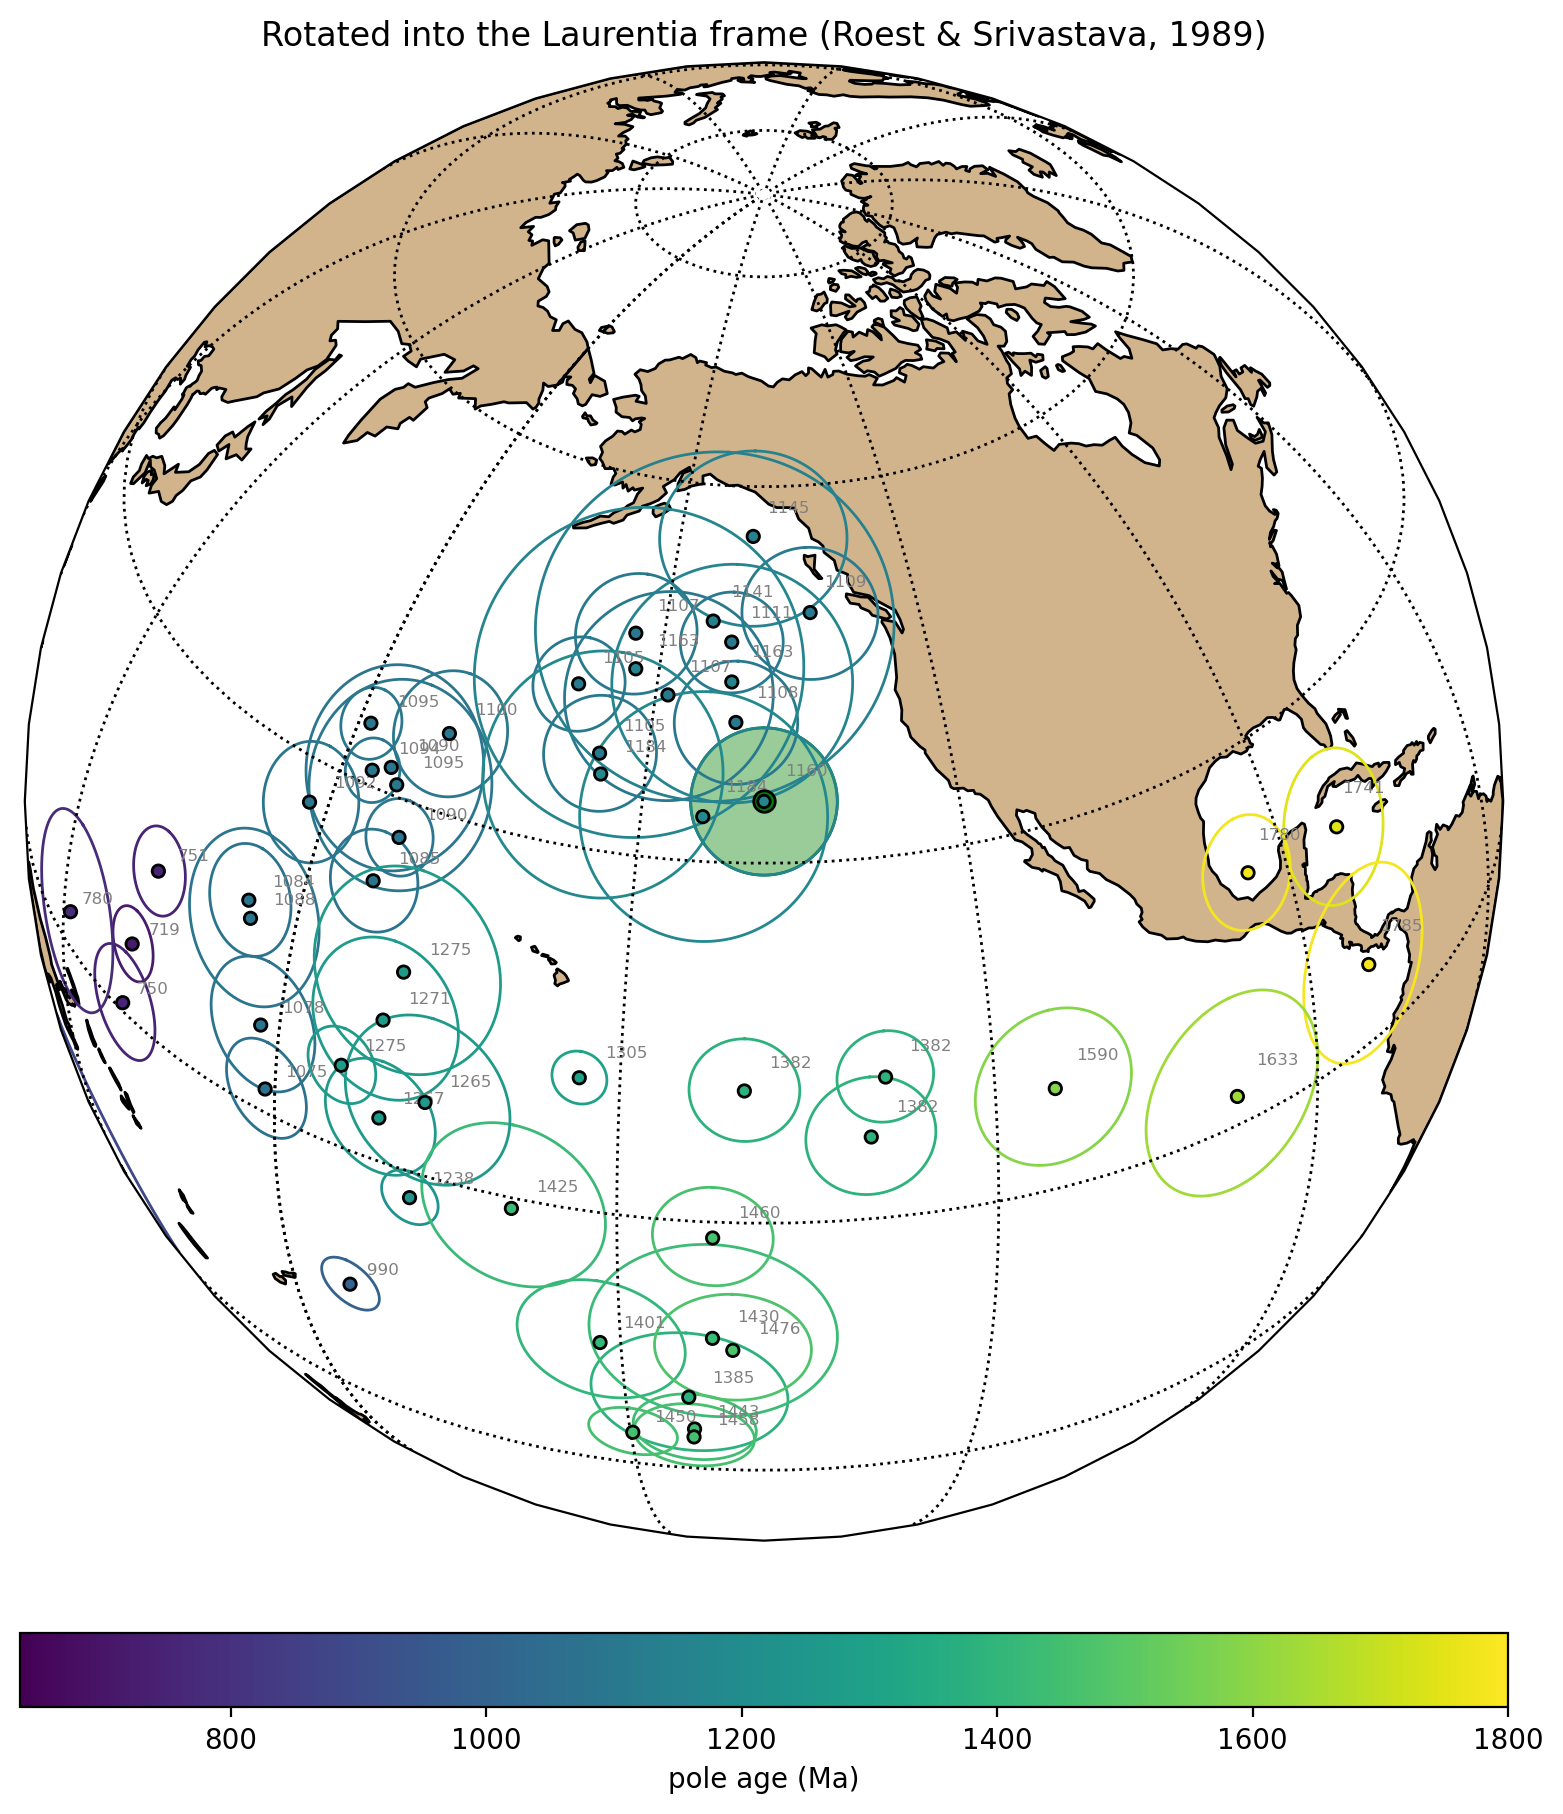

In [6]:
ax = pt.plot_apwp_context(Laurentia_poles, pole_rotated['inc'], pole_rotated['dec'],
                          pole_rotated['alpha95'], age_min=635, age_max=1800,
                          projection='orthographic',
                          central_longitude=pole_rotated['dec'],
                          central_latitude=pole_rotated['inc'])
plt.title('Rotated into the Laurentia frame (Roest & Srivastava, 1989)')
plt.show()

## Comparison with younger Laurentia poles

The `plot_pole_overlap` comparison is shown for both the unrotated and the rotated position.

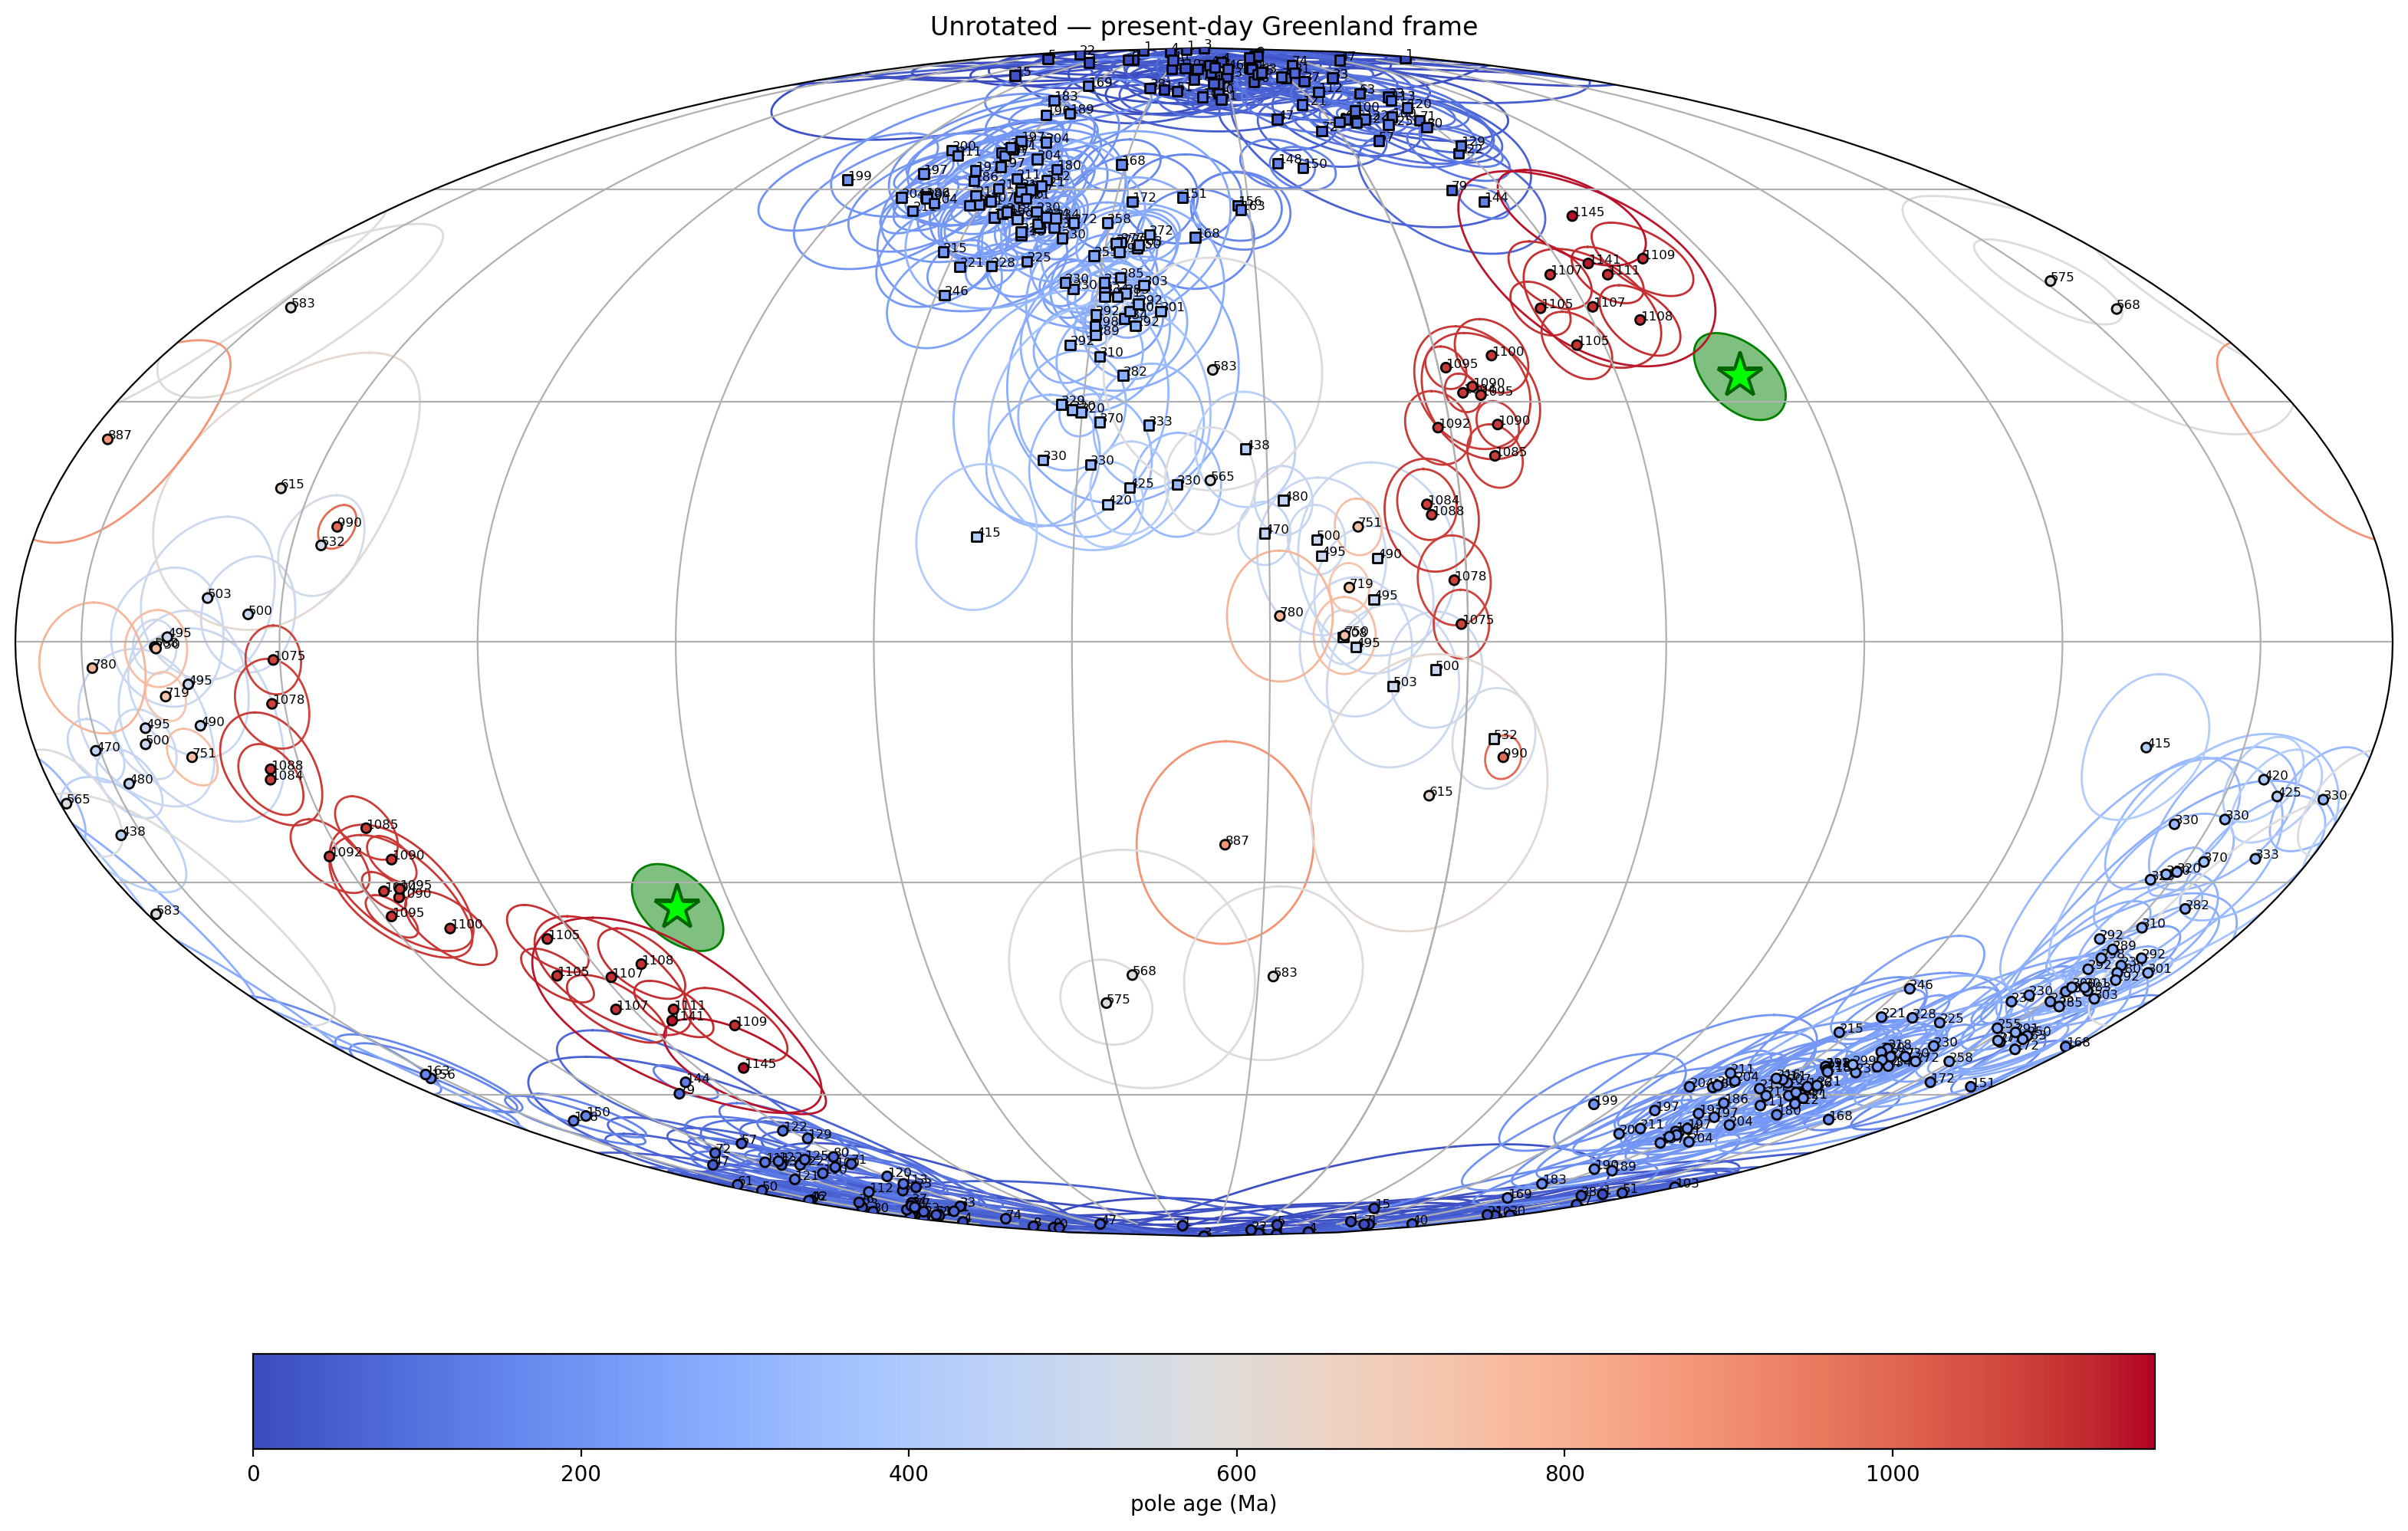

In [7]:
pt.plot_pole_overlap('NE-SW Trending Dyke Swarm', Laurentia_stricto_poles, pt.Torsvik2012_Laurentia,
                     pole_plat=pole_mean['inc'], pole_plon=pole_mean['dec'],
                     pole_A95=pole_mean['alpha95'], pole_age=1160, show=False)
plt.title('Unrotated \u2014 present-day Greenland frame')
plt.show()

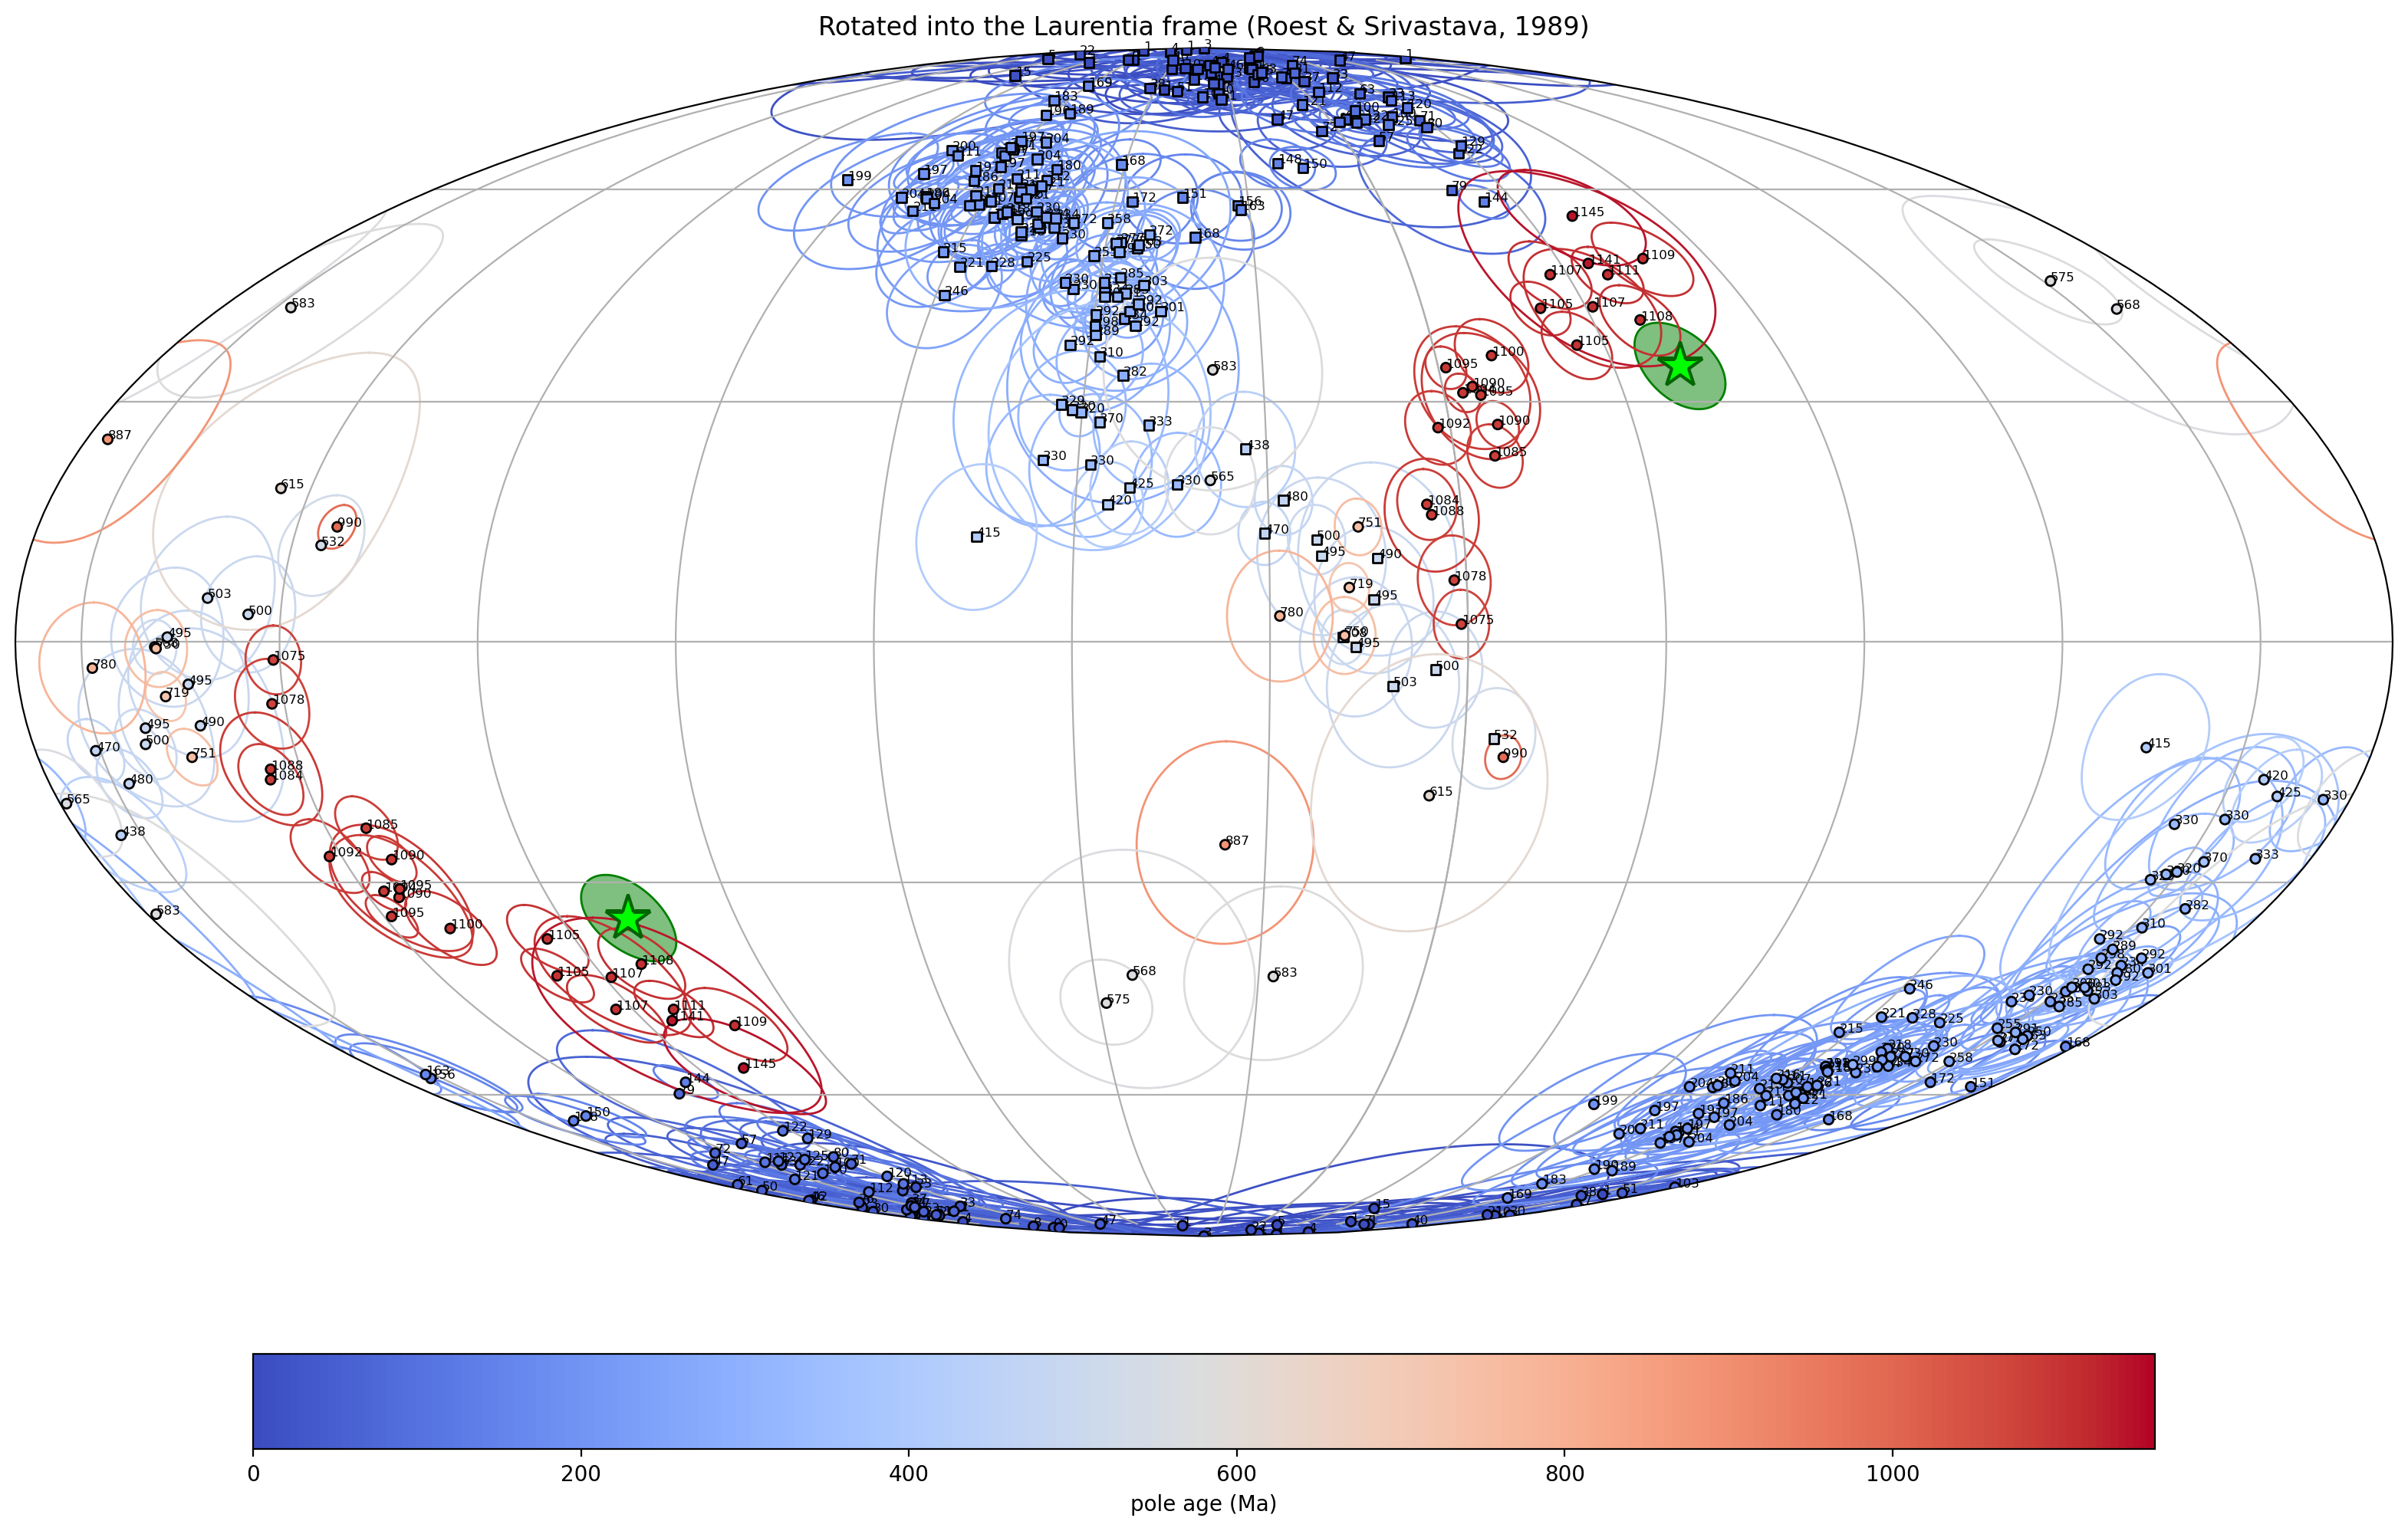

In [8]:
pt.plot_pole_overlap('NE-SW Trending Dyke Swarm', Laurentia_stricto_poles, pt.Torsvik2012_Laurentia,
                     pole_plat=pole_rotated['inc'], pole_plon=pole_rotated['dec'],
                     pole_A95=pole_rotated['alpha95'], pole_age=1160, show=False)
plt.title('Rotated into the Laurentia frame (Roest & Srivastava, 1989)')
plt.show()

## Nordic workshop summary

The pole is exported in the Nordic compilation format. The R-criteria scores, pole position, mean direction, and source-publication metadata are carried from the Evans et al. (2021) compilation; the nominal age, age bounds (lomagage/himagage), and the compilation method note are taken from the age-constraint section of the first markdown cell. The pole is exported in its unrotated, present-day Greenland coordinates; the rotation into the Laurentia frame is applied above only for the APWP comparison.

In [9]:
R2, R3, R5, R6, R7 = (int(float(row[k])) for k in ['2', '3', '5', '6', '7'])
R4 = '' if float(row['4']) != 0 else ''

sites = pd.DataFrame([{'dir_tilt_correction': int(float(row['TILT'])),
                       'dir_n_samples': int(float(row['N']))}])

summary = pt.make_nordic_summary(
    terrane='Laurentia-Greenland',
    rockname='NE-SW Trending Dyke Swarm',
    sites=sites,
    dir_mean=dir_mean,
    pole_mean=pole_mean,
    study_lon=float(row['SLONG']),
    study_lat=float(row['SLAT']),
    component_comment='Characteristic remanent magnetization; mean for the NE-SW trending dyke swarm (Gardar Province, South Greenland)',
    tests='',
    gpmdb_number='',
    magic_id='',
    percent_reversed='',
    demag_code='',
    R1=1, R2=R2, R3=R3, R4=R4, R5=R5, R6=R6, R7=R7, Grade=row['Grade'],
    nominal_age=1160, lomagage=1155, himagage=1165,
    REF_method='Younger than the ca. 1163 Ma giant dykes and older than the 1156 +/- 1 Ma central Tugtutoq pluton (as compiled by Evans et al., 2021).',
    POLE_AUTHORS=row['POLE AUTHORS'],
    YEAR=int(float(row['YEAR'])),
    JOURNAL=row['JOURNAL'],
    VOLUME=str(row['VOLUME']),
    VPAGES=str(row['VPAGES']),
    TITLE=row['TITLE'],
    COMMENT='Pole taken from the Evans et al. (2021) Laurentia compilation (Piper, 1992); no site-level directions digitized here. Source compilation lists %REV as 0or100 (ambiguous polarity assignment). Nominal age, age bounds, and the compilation method note are carried from the notebook age-constraint section.'
)
pt.save_nordic_summary(summary, '1160_NE-SW')
summary

,Terrane,ROCKNAME,RESULT#,COMPONENT,TESTS,TILT,SLAT,SLONG,B,N,...,himagage,REF/method,ROCKNAME,POLE AUTHORS,YEAR,JOURNAL,VOLUME,VPAGES,TITLE,Comment
0,Laurentia-Greenland,NE-SW Trending Dyke Swarm,,Characteristic remanent magnetization; mean fo...,,0,61.2,314.6,18,102,...,1165,Younger than the ca. 1163 Ma giant dykes and o...,NE-SW Trending Dyke Swarm,"Piper, J.D.A.",1992,Precambr.Res.,54,153-172,The palaeomagnetism of major (Middle Proterozo...,Pole taken from the Evans et al. (2021) Lauren...
